In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch

from torchvision.io.image import read_image
from torchvision.utils import draw_bounding_boxes
from torchvision.transforms.functional import to_pil_image
from torchvision.models.detection import retinanet_resnet50_fpn_v2, RetinaNet_ResNet50_FPN_V2_Weights
from torchvision import tv_tensors

import matplotlib.pyplot as plt

In [2]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cuda device


In [3]:
CLASSES = ['L1/L2', 'L2/L3', 'L3/L4', 'L4/L5', 'L5/S1']
BATCH_SIZE = 16
IMG_SIZE = 420
NUM_EPOCHS = 10
DATA_PATH="D:/ML/RSNA2024"

## Data Loading

In [4]:
import json

with open(os.path.join(DATA_PATH, "project-1-at-2024-08-29-11-46-bfb9d6bc.json"), "r") as f:
    annot=json.load(f)

In [5]:
annot[250]

{'id': 944,
 'annotations': [{'id': 251,
   'completed_by': 1,
   'result': [{'original_width': 420,
     'original_height': 420,
     'image_rotation': 0,
     'value': {'x': 44.47403462050599,
      'y': 76.2982689747004,
      'width': 12.11717709720373,
      'height': 10.519307589880157,
      'rotation': 0,
      'rectanglelabels': ['L5/S1']},
     'id': 'OOw_ViQJBQ',
     'from_name': 'label',
     'to_name': 'image',
     'type': 'rectanglelabels',
     'origin': 'manual'},
    {'original_width': 420,
     'original_height': 420,
     'image_rotation': 0,
     'value': {'x': 39.54727030625832,
      'y': 67.50998668442078,
      'width': 13.315579227696404,
      'height': 6.924101198402127,
      'rotation': 0,
      'rectanglelabels': ['L4/L5']},
     'id': 'CH9dF8UkfX',
     'from_name': 'label',
     'to_name': 'image',
     'type': 'rectanglelabels',
     'origin': 'manual'},
    {'original_width': 420,
     'original_height': 420,
     'image_rotation': 0,
     'value': {

In [6]:
# convert from LS percent units to pixels 
def convert_from_ls(result):
    if 'original_width' not in result or 'original_height' not in result:
        return None

    value = result['value']
    w, h = result['original_width'], result['original_height']

    if all([key in value for key in ['x', 'y', 'width', 'height']]):
        return w * value['x'] / 100.0, \
               h * value['y'] / 100.0, \
               w * value['width'] / 100.0, \
               h * value['height'] / 100.0

# convert from pixels to LS percent units 
def convert_to_ls(x, y, width, height, original_width, original_height):
    return x / original_width * 100.0, y / original_height * 100.0, \
           width / original_width * 100.0, height / original_height * 100

In [7]:
#Boxes = [xmin, ymin, xmax, ymax]

files=[]
targets=[]


for i, a in enumerate(annot):
    fileName = a["data"]["image"].split("?d=")[1]
    fileNameParts = fileName.split("%5C")
    absolutePath = os.path.join(DATA_PATH, fileNameParts[1], fileNameParts[2], fileNameParts[3])
    annotResults = a["annotations"]
    boxesAll=[]
    labelsAll=[]
    for annotRes in annotResults:
        for resEl in annotRes["result"]:
            output = convert_from_ls(resEl)
            if output is None:
                raise Exception('Wrong convert') 
            pixelX, pixelY, pixelW, pixelH = output
            box = [pixelX, pixelY, pixelX+pixelW, pixelY+pixelH]
            boxesAll.append(box)
            labelsAll.append(resEl["value"]["rectanglelabels"][0])
    files.append(absolutePath)
    targets.append({"boxes": boxesAll, "labels": labelsAll})

In [8]:
targets[250]

{'boxes': [[186.79094540612513,
   320.45272969374173,
   237.6830892143808,
   364.6338215712384],
  [166.09853528628494,
   283.5419440745673,
   222.02396804260985,
   312.62316910785626],
  [162.18375499334218,
   236.56458055925435,
   219.78695073235681,
   263.4087882822903],
  [178.96138482023966,
   182.87616511318242,
   230.4127829560586,
   212.5166444740346],
  [195.7390146471371,
   133.10252996005326,
   246.0719041278295,
   165.53928095872172]],
 'labels': ['L5/S1', 'L4/L5', 'L3/L4', 'L2/L3', 'L1/L2']}

In [9]:
keys = CLASSES
values = np.arange(0,len(CLASSES))
classMapping = dict(zip(keys, values))
classMapping

{'L1/L2': 0, 'L2/L3': 1, 'L3/L4': 2, 'L4/L5': 3, 'L5/S1': 4}

In [10]:
values = CLASSES
keys = np.arange(0,len(CLASSES))
IntToClass= dict(zip(keys, values))

In [11]:
class ObjDetDataset(torch.utils.data.Dataset):
    def __init__(self, data):
        self.data = data
        self.augment=False

    def __getitem__(self, idx):
        # load images and masks
        img_path =  self.data[idx][0]
        img = read_image(img_path)
        img = img.float() / 255.0

        boxes = self.data[idx][1]["boxes"]

        labels = self.data[idx][1]["labels"]

        if len(boxes)==0:
            boxes = torch.zeros((0, 4), dtype=torch.float32).to(device)
            labels = torch.zeros((0,), dtype=torch.int64).to(device)

        image_id = idx

        # Wrap sample and targets into torchvision tv_tensors:
        img = tv_tensors.Image(img)

        mappedLabels = [classMapping[el] for el in labels]

        target = {}
        target["boxes"] = tv_tensors.BoundingBoxes(boxes, format="XYXY", canvas_size=img.shape)
        target["labels"] = torch.tensor(mappedLabels).type(torch.long)
        target["image_id"] = image_id

        if self.augment:
            img, target = self.transforms(img, target)

        return img, target

    def __len__(self):
        return len(self.data)

In [12]:
from torch.utils.data import DataLoader

def collate_fn(batch):
    return tuple(zip(*batch))

import random
random.seed(474932)

trainValSplit=0.7

shuffledData = list(zip(files,targets))
random.shuffle(shuffledData)
valSplit = int(len(shuffledData)*trainValSplit)

print(f"# Training samples: {valSplit}/{len(shuffledData)}")

trainData = shuffledData[0:valSplit]
valData = shuffledData[valSplit:]

trainDataset = ObjDetDataset(trainData)
valDataset = ObjDetDataset(valData)

trainDataloader = DataLoader(trainDataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
valDataloader = DataLoader(valDataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)

# Training samples: 210/300


Feature batch: torch.Size([1, 420, 420])
Labels batch: {'boxes': BoundingBoxes([], device='cuda:0', size=(0, 4), format=BoundingBoxFormat.XYXY, canvas_size=torch.Size([1, 420, 420])), 'labels': tensor([], dtype=torch.int64), 'image_id': 22}


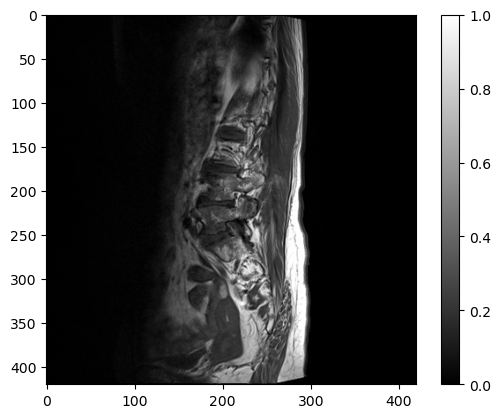

In [13]:
train_features, train_labels = next(iter(trainDataloader))
print(f"Feature batch: {train_features[0].shape}")
print(f"Labels batch: {train_labels[0]}")
img = train_features[0].squeeze()
label = train_labels[0]

fig, ax = plt.subplots()
im = ax.imshow(img, cmap='gray')
fig.colorbar(im, orientation='vertical')
plt.show()

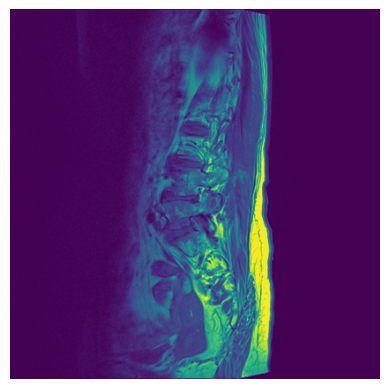

In [14]:
def plotImageWithAnnot(im, target, filename=None):
    fig, ax = plt.subplots()
    ax.imshow(im)
    plt.axis('off')

    for idx,b in enumerate(target["boxes"]):
        b = b.numpy()
        rect = patches.Rectangle((b[0], b[1]), b[2]-b[0], b[3]-b[1], linewidth=1, edgecolor='r', facecolor='none')
        ax.add_patch(rect)
        plt.text(b[0], b[1]-4, IntToClass[target["labels"].numpy()[idx]], {"color":"red"})
    if filename:
        plt.title(filename)
        plt.tight_layout()
        plt.savefig(os.path.join(DATA_PATH, f"objDetExamples/{filename}.png"), dpi=120)
        plt.close()
    else:
        plt.show()

plotImageWithAnnot(img, train_labels[0])

## Model

In [15]:
import torchvision
import torch
from functools import partial
from torchvision.models.detection import RetinaNet_ResNet50_FPN_V2_Weights
from torchvision.models.detection.retinanet import RetinaNetClassificationHead, RetinaNet
from torchvision.models.mobilenetv2 import MobileNet_V2_Weights
from torchvision.models.detection.anchor_utils import AnchorGenerator

def create_model(num_classes):
    model = torchvision.models.detection.retinanet_resnet50_fpn_v2(
        weights=RetinaNet_ResNet50_FPN_V2_Weights.COCO_V1
    )
    num_anchors = model.head.classification_head.num_anchors
    model.head.classification_head = RetinaNetClassificationHead(
        in_channels=256,
        num_anchors=num_anchors,
        num_classes=num_classes,
        norm_layer=partial(torch.nn.GroupNorm, 32)
    )
    return model



model = create_model(len(CLASSES))
# model.eval()
# x = [torch.rand(3, 300, 400), torch.rand(3, 500, 400)]
# predictions = model(x)
# print(predictions)
model.to(device)

RetinaNet(
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      

In [16]:
import math
from torchmetrics.detection import MeanAveragePrecision



num_epochs = 100
earlyStoppingPatience=5
printFreq=3


optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

# Decrease LR every step_size epochs by factor gamma
# lr_scheduler = torch.optim.lr_scheduler.StepLR(
#     optimizer,
#     step_size=3,
#     gamma=0.9
# )

metric=MeanAveragePrecision(box_format="xyxy").to(device)
metricVal=MeanAveragePrecision(box_format="xyxy").to(device)

scaler = torch.amp.GradScaler(enabled=True)

def train(model, optimizer, data_loader, device, epoch, scaler=None):
    model.train()
    print( f"\nEpoch: {epoch+1}")

    lr_scheduler = None
    if epoch == 0:
        # Warm up learning rate by going from 0.001 to 1*init_LR during the first epoch
        warmup_factor = 1.0 / 1000
        warmup_iters = min(1000, len(data_loader) - 1)
        lr_scheduler = torch.optim.lr_scheduler.LinearLR(
            optimizer, start_factor=warmup_factor, total_iters=warmup_iters
        )

    for step, (images, targets) in enumerate(data_loader):
        images = list(image.to(device) for image in images)
        
        # Handle null instances (images with no objects)
        for target in targets:
            if len(target['boxes']) == 0:
                target['boxes'] = torch.zeros((0, 4), dtype=torch.float32).to(device)
                target['labels'] = torch.zeros((0,), dtype=torch.int64).to(device)

        targets = [{k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in t.items()} for t in targets]
        with torch.autocast(device_type=device, dtype=torch.float16, enabled=scaler is not None):
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())

        losses_reduced = sum(loss for loss in loss_dict.values())

        lossValue = losses_reduced.item()
        
        if step%printFreq ==0:
            print(f"{lossValue}")

        if not math.isfinite(lossValue):
            print(f"Loss is {lossValue}, stopping training")
            print(loss_dict)
            raise Exception()

        optimizer.zero_grad()
        if scaler is not None:
            scaler.scale(losses).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            losses.backward()
            optimizer.step()

        if lr_scheduler is not None:
            lr_scheduler.step()

@torch.no_grad()
def evaluate(model, data_loader, device, epoch):
    model.eval()

    for step, (images, targets) in enumerate(data_loader):
        images = list(image.to(device) for image in images)
        
        # Handle null instances (images with no objects)
        for target in targets:
            if len(target['boxes']) == 0:
                target['boxes'] = torch.zeros((0, 4), dtype=torch.float32).to(device)
                target['labels'] = torch.zeros((0,), dtype=torch.int64).to(device)

        targetsCuda = [{k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in t.items()} for t in targets]
        
        preds = model(images)
        if step%printFreq ==0:
            plotImageWithAnnot(images[0].detach().cpu().numpy()[0,:,:], targets[0], f"epoch{epoch}_step{step}")

        metricVal.update(preds, targetsCuda)

    results = metricVal.compute()
    print(f"Validation Loss: {results}")
    return results["map"].detach().cpu().numpy()

bestMap=0
bestEpoch=0

for epoch in range(num_epochs):
    train(model, optimizer, trainDataloader, device, epoch, scaler=scaler)
    valMap = evaluate(model, valDataloader, device, epoch)
   
    if valMap>bestMap:
        bestMap=valMap
        bestEpoch=epoch
        print(f"New best MAP: {bestMap:.5f}")
    if epoch-bestEpoch>earlyStoppingPatience:
        print("Early Stopping")
        break
    
print("Done!")


Epoch: 1
1.2766284942626953
1.0233557224273682
0.8826845288276672
Validation Loss: {'map': tensor(0.), 'map_50': tensor(0.), 'map_75': tensor(0.), 'map_small': tensor(0.), 'map_medium': tensor(0.), 'map_large': tensor(-1.), 'mar_1': tensor(0.), 'mar_10': tensor(0.), 'mar_100': tensor(0.), 'mar_small': tensor(0.), 'mar_medium': tensor(0.), 'mar_large': tensor(-1.), 'map_per_class': tensor(-1.), 'mar_100_per_class': tensor(-1.), 'classes': tensor([0, 1, 2, 3, 4], dtype=torch.int32)}

Epoch: 2
0.7634136080741882
0.9705185890197754
0.8337385058403015
Validation Loss: {'map': tensor(0.), 'map_50': tensor(0.), 'map_75': tensor(0.), 'map_small': tensor(0.), 'map_medium': tensor(0.), 'map_large': tensor(-1.), 'mar_1': tensor(0.), 'mar_10': tensor(0.), 'mar_100': tensor(0.), 'mar_small': tensor(0.), 'mar_medium': tensor(0.), 'mar_large': tensor(-1.), 'map_per_class': tensor(-1.), 'mar_100_per_class': tensor(-1.), 'classes': tensor([0, 1, 2, 3, 4], dtype=torch.int32)}

Epoch: 3
0.62751102447509

c:\Users\manue\anaconda3\envs\ml\Lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)  # noqa: B028


Validation Loss: {'map': tensor(0.0420), 'map_50': tensor(0.0701), 'map_75': tensor(0.0446), 'map_small': tensor(0.0717), 'map_medium': tensor(0.0422), 'map_large': tensor(-1.), 'mar_1': tensor(0.0789), 'mar_10': tensor(0.2513), 'mar_100': tensor(0.2579), 'mar_small': tensor(0.1356), 'mar_medium': tensor(0.2690), 'mar_large': tensor(-1.), 'map_per_class': tensor(-1.), 'mar_100_per_class': tensor(-1.), 'classes': tensor([0, 1, 2, 3, 4], dtype=torch.int32)}
New best MAP: 0.04201

Epoch: 5
0.3751932680606842
0.26173505187034607
0.3307183086872101
Validation Loss: {'map': tensor(0.0633), 'map_50': tensor(0.1040), 'map_75': tensor(0.0695), 'map_small': tensor(0.0924), 'map_medium': tensor(0.0641), 'map_large': tensor(-1.), 'mar_1': tensor(0.1006), 'mar_10': tensor(0.3178), 'mar_100': tensor(0.3249), 'mar_small': tensor(0.2034), 'mar_medium': tensor(0.3370), 'mar_large': tensor(-1.), 'map_per_class': tensor(-1.), 'mar_100_per_class': tensor(-1.), 'classes': tensor([0, 1, 2, 3, 4], dtype=torc

In [ ]:
#TODO:
# Augmentation with Albumentations